## IMDB Movie-Dataset Analysis

In [1]:
# Imports

# Data Handling & Analysis 
import pandas as pd 
import numpy as np 

# Data Visualization
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
# Load IMDB Movie-dataset

df = pd.read_csv('imdb_movie_dataset.csv')
df.head()

,Rank,Title,Genre,Description,Director,Actors,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
0,1,Guardians of the Galaxy,"Action,Adventure,Sci-Fi",A group of intergalactic criminals are forced ...,James Gunn,"Chris Pratt, Vin Diesel, Bradley Cooper, Zoe S...",2014,121,8.1,757074,333.13,76.0
1,2,Prometheus,"Adventure,Mystery,Sci-Fi","Following clues to the origin of mankind, a te...",Ridley Scott,"Noomi Rapace, Logan Marshall-Green, Michael Fa...",2012,124,7.0,485820,126.46,65.0
2,3,Split,"Horror,Thriller",Three girls are kidnapped by a man with a diag...,M. Night Shyamalan,"James McAvoy, Anya Taylor-Joy, Haley Lu Richar...",2016,117,7.3,157606,138.12,62.0
3,4,Sing,"Animation,Comedy,Family","In a city of humanoid animals, a hustling thea...",Christophe Lourdelet,"Matthew McConaughey,Reese Witherspoon, Seth Ma...",2016,108,7.2,60545,270.32,59.0
4,5,Suicide Squad,"Action,Adventure,Fantasy",A secret government agency recruits some of th...,David Ayer,"Will Smith, Jared Leto, Margot Robbie, Viola D...",2016,123,6.2,393727,325.02,40.0


### Data Inspection

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Rank                1000 non-null   int64  
 1   Title               1000 non-null   object 
 2   Genre               1000 non-null   object 
 3   Description         1000 non-null   object 
 4   Director            1000 non-null   object 
 5   Actors              1000 non-null   object 
 6   Year                1000 non-null   int64  
 7   Runtime (Minutes)   1000 non-null   int64  
 8   Rating              1000 non-null   float64
 9   Votes               1000 non-null   int64  
 10  Revenue (Millions)  872 non-null    float64
 11  Metascore           936 non-null    float64
dtypes: float64(3), int64(4), object(5)
memory usage: 93.9+ KB


In [4]:
df.describe()

,Rank,Year,Runtime (Minutes),Rating,Votes,Revenue (Millions),Metascore
count,1000.000000,1000.000000,1000.000000,1000.000000,1.000000e+03,872.000000,936.000000
mean,500.500000,2012.783000,113.172000,6.723200,1.698083e+05,82.956376,58.985043
std,288.819436,3.205962,18.810908,0.945429,1.887626e+05,103.253540,17.194757
min,1.000000,2006.000000,66.000000,1.900000,6.100000e+01,0.000000,11.000000
25%,250.750000,2010.000000,100.000000,6.200000,3.630900e+04,13.270000,47.000000
50%,500.500000,2014.000000,111.000000,6.800000,1.107990e+05,47.985000,59.500000
75%,750.250000,2016.000000,123.000000,7.400000,2.399098e+05,113.715000,72.000000
max,1000.000000,2016.000000,191.000000,9.000000,1.791916e+06,936.630000,100.000000


In [5]:
missing_values = df.isnull().sum().sort_values(ascending=False)
missing_values

Revenue (Millions)    128
Metascore              64
Rank                    0
Title                   0
Description             0
Genre                   0
Director                0
Actors                  0
Runtime (Minutes)       0
Year                    0
Votes                   0
Rating                  0
dtype: int64

### Data Cleaning

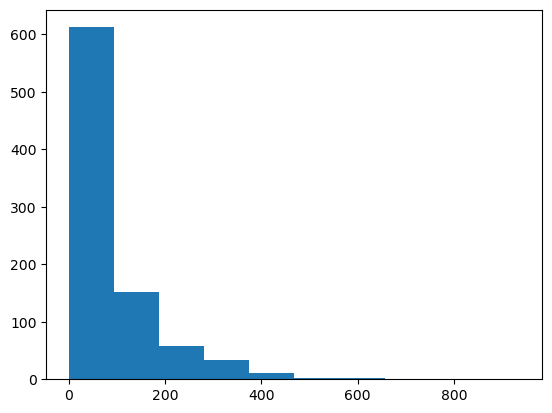

In [6]:
# Removing Unneeded Columns
df.drop(columns=['Director','Description','Actors','Runtime (Minutes)','Metascore'])

# Filling Missing Values

# Revenue col have 128 missing value to fill it with mean or median 
# check for the distribution of the data... if symmetric: mean , if Skewed: then Median

plt.hist(df['Revenue (Millions)'])
plt.show()

In [7]:
# 'Revenue (Millions)' has missing values; imputing with median due to skewness

df['Revenue (Millions)'] = df['Revenue (Millions)'].fillna(
    df['Revenue (Millions)'].median()
)

In [8]:
df.isnull().sum()

Rank                   0
Title                  0
Genre                  0
Description            0
Director               0
Actors                 0
Year                   0
Runtime (Minutes)      0
Rating                 0
Votes                  0
Revenue (Millions)     0
Metascore             64
dtype: int64

### Exploartory Data Analysis 

Text(0.5, 1.0, 'Distribution of Movie Rating')

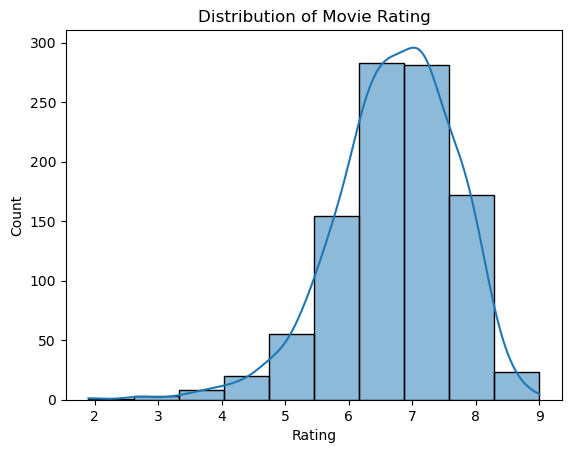

In [9]:
# What is the distribution of movie ratings?
sns.histplot(df['Rating'], bins=10,kde=True)
plt.title('Distribution of Movie Rating')

Most movies have ratings clustered between 5 and 8, centered around 6.5–7, indicating generally positive audience reception.

Text(0.5, 1.0, 'Distribution of Popularity')

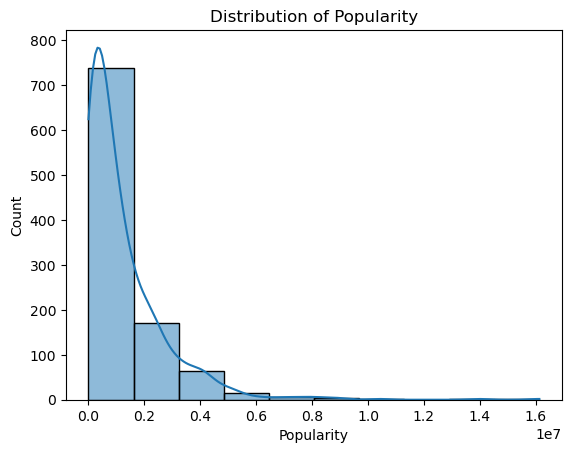

In [10]:
# What is the distribution of popularity?

# Create a weighted popularity score column
df['Popularity'] = df['Rating'] * df['Votes']

# Distribution plot 
sns.histplot(df['Popularity'], bins=10, kde=True)
plt.title('Distribution of Popularity')

 Popularity distribution is highly right-skewed with most movies having low popularity A few movies have very high popularity scores, causing a long tail
Consider log transformation for modeling and segment movies by popularity groups

In [11]:
# Which movies have the highest ratings?

top_rated_movies = df[['Title','Rating']].sort_values(by='Rating',ascending=False).head(5)
top_rated_movies

,Title,Rating
54,The Dark Knight,9.0
80,Inception,8.8
117,Dangal,8.8
36,Interstellar,8.6
249,The Intouchables,8.6


C:\Users\Admin\AppData\Local\Temp\ipykernel_2912\3818611096.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Rating', y='Title', data=top_rated_movies, palette='viridis')


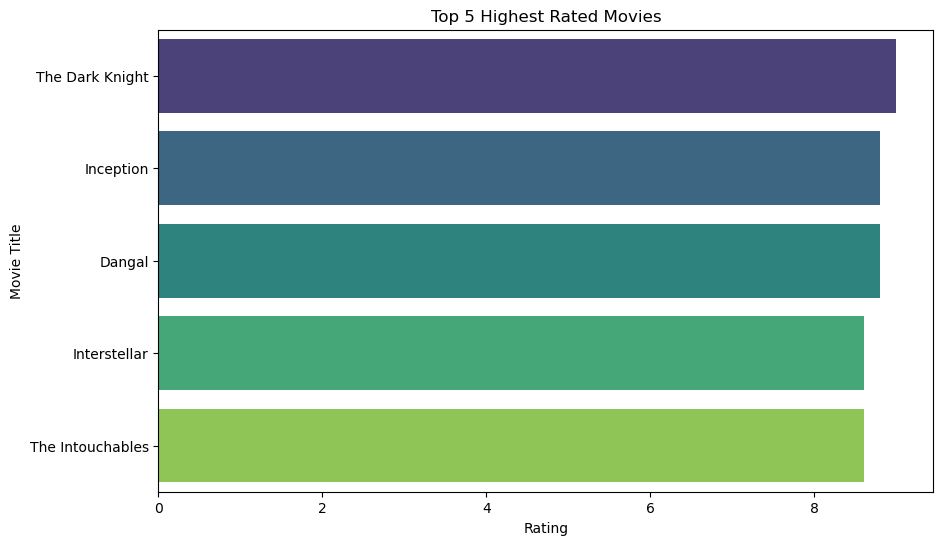

In [12]:
plt.figure(figsize=(10,6))
sns.barplot(x='Rating', y='Title', data=top_rated_movies, palette='viridis')
plt.title('Top 5 Highest Rated Movies')
plt.xlabel('Rating')
plt.ylabel('Movie Title')
plt.show()

In [13]:
popular_movies = df[['Title','Popularity']].sort_values(by='Popularity',ascending=False).head(5)
popular_movies

,Title,Popularity
54,The Dark Knight,16127244.0
80,Inception,13935900.0
124,The Dark Knight Rises,10392482.5
36,Interstellar,9010624.2
144,Django Unchained,8728566.0


([0, 1, 2, 3, 4],
 [Text(0, 0, 'The Dark Knight'),
  Text(1, 0, 'Inception'),
  Text(2, 0, 'The Dark Knight Rises'),
  Text(3, 0, 'Interstellar'),
  Text(4, 0, 'Django Unchained')])

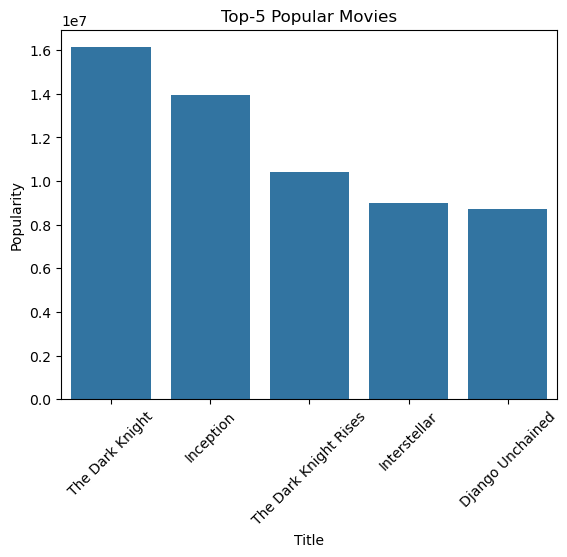

In [14]:
sns.barplot(x='Title',y='Popularity',data=popular_movies)
plt.title('Top-5 Popular Movies')
plt.xticks(rotation=45)


In [15]:
# What are the most common genres?


# Most common genres (mode)
top_genres = df['Genre'].mode()

# Filter movies that belong to the top genre
top_genre_movies = df[df['Genre'].isin(top_genres)][['Title','Rating']]
top_10 = top_genre_movies.head(10)
top_10

,Title,Rating
0,Guardians of the Galaxy,8.1
12,Rogue One,7.9
24,Independence Day: Resurgence,5.3
32,X-Men: Apocalypse,7.1
35,Captain America: Civil War,7.9
48,Star Trek Beyond,7.1
60,Batman v Superman: Dawn of Justice,6.7
67,Mad Max: Fury Road,8.1
80,Inception,8.8
85,Jurassic World,7.0


Text(0.5, 1.0, 'Most Common Genres')

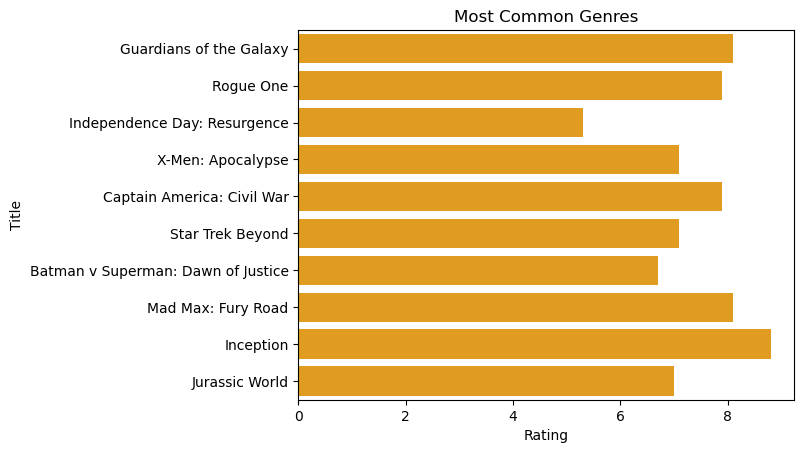

In [16]:
sns.barplot(x='Rating',y='Title',data=top_10,color='orange')
plt.title('Most Common Genres')

## Genre-Based Analysis

In [57]:
# What is the average rating per genre? 
top_10_genres = df['Genre'].value_counts().head(10).index
top_10_df = df[df['Genre'].isin(top_10_genres)]
avg_rating = top_10_df.groupby('Genre')['Rating'].mean()

Text(0.5, 1.0, 'Averge Rating Per Genre')

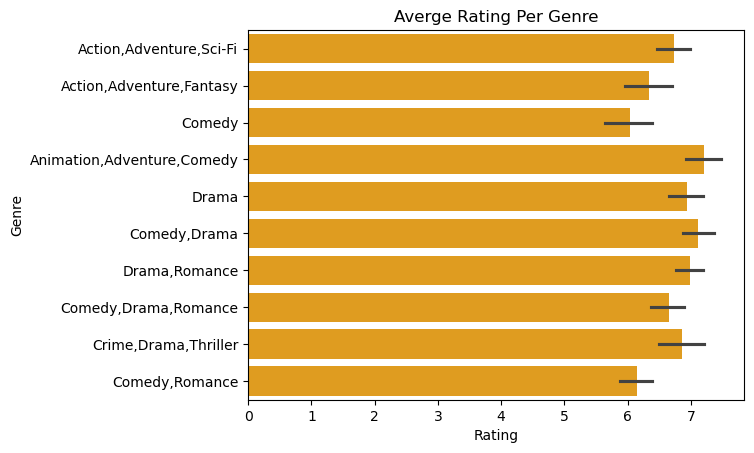

In [18]:
sns.barplot(x='Rating',y='Genre',data=top_10_df,color='orange')
plt.title('Averge Rating Per Genre')

In [19]:
# Which genre has the highest-rated movies?

High_rmovie = df.groupby('Genre')['Rating'].max()
highest_rmovie_Genre = High_rmovie.idxmax()
print('Genre, With Hightest-Rated Movies: ', highest_rmovie_Genre)

Genre, With Hightest-Rated Movies:  Action,Crime,Drama


In [20]:
# Which genre is the most popular overall?

popular_genre = df.groupby('Genre')['Popularity'].mean()
most_popular = popular_genre.idxmax()                          # idxmax(): Give the NAME (label) of highest value 
print('Most Popular Genre: ', most_popular)

Most Popular Genre:  Drama,Western


In [44]:
# Which genre appears the most?

freq_genre = df['Genre'].mode()
print('Genre Appears Most is: ', freq_genre)

Genre Appears Most is:  0    Action,Adventure,Sci-Fi
Name: Genre, dtype: object


### Trend Analysis (Time-Based)

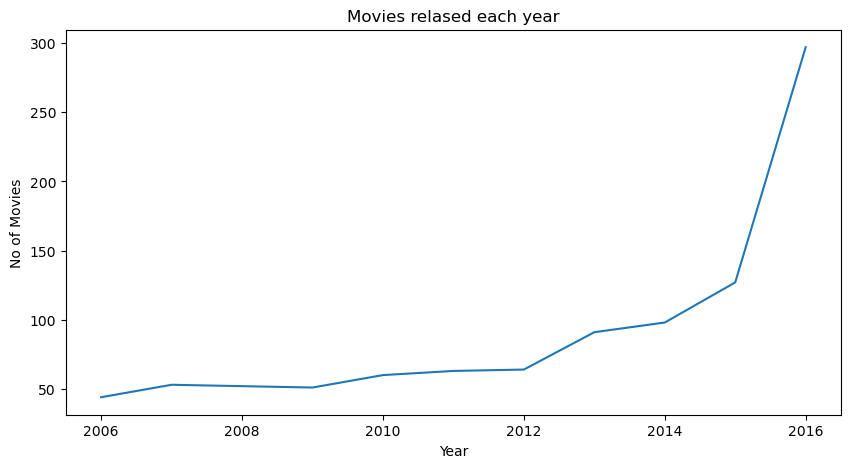

In [56]:
# How many movies are released each year?

nos_movies = df.groupby('Year')['Title'].count()
plt.figure(figsize=(10,5))
plt.plot(nos_movies.index,nos_movies.values)
plt.title('Movies relased each year')
plt.xlabel('Year')
plt.ylabel('No of Movies')
plt.show()

Text(0, 0.5, 'Popularity')

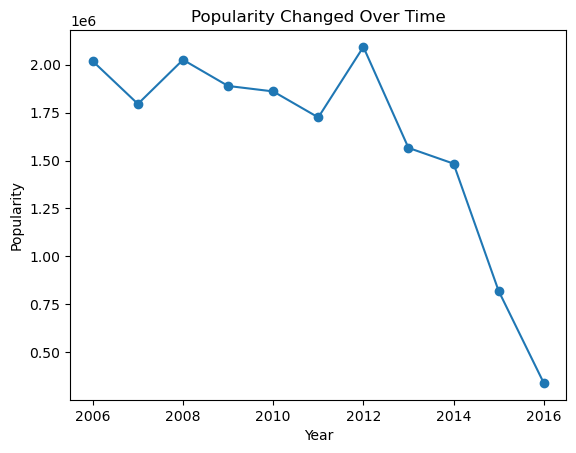

In [25]:
# How has popularity changed over time?
avg_m = df.groupby('Year')['Popularity'].mean()
plt.plot(avg_m.index,avg_m.values,marker='o')
plt.title('Popularity Changed Over Time')
plt.xlabel('Year')
plt.ylabel('Popularity')

### Relationship Analysis

Text(0.5, 1.0, 'Relationship B/W Rating vs Popularity')

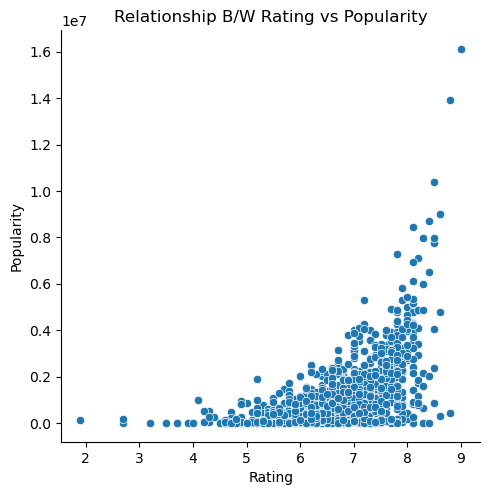

In [26]:
# Is there a relationship between rating and popularity?

sns.relplot(data=df,x='Rating',y='Popularity',kind='scatter')
plt.title('Relationship B/W Rating vs Popularity')


Not a Perfect Relationship But There is a positive relationship between Rating and Popularity. As rating incresases, Popularity also increases

In [27]:
# Correlation between Rating and Popularity 

corr_value = df['Rating'].corr(df['Popularity'])
corr_value

np.float64(0.5413784205459953)

## Top & Bottom Analysis

In [29]:
# Top 10 highest-rated movies

highest_rmovies = df.groupby('Title')['Rating'].mean().sort_values(ascending=False).head(10)
highest_rmovies

Title
The Dark Knight          9.0
Inception                8.8
Dangal                   8.8
Kimi no na wa            8.6
Interstellar             8.6
The Intouchables         8.6
Taare Zameen Par         8.5
The Dark Knight Rises    8.5
Whiplash                 8.5
The Departed             8.5
Name: Rating, dtype: float64

C:\Users\Admin\AppData\Local\Temp\ipykernel_2912\3257351039.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hr_df,x='Title',y='Rating',palette='viridis')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'The Dark Knight'),
  Text(1, 0, 'Inception'),
  Text(2, 0, 'Dangal'),
  Text(3, 0, 'Kimi no na wa'),
  Text(4, 0, 'Interstellar'),
  Text(5, 0, 'The Intouchables'),
  Text(6, 0, 'Taare Zameen Par'),
  Text(7, 0, 'The Dark Knight Rises'),
  Text(8, 0, 'Whiplash'),
  Text(9, 0, 'The Departed')])

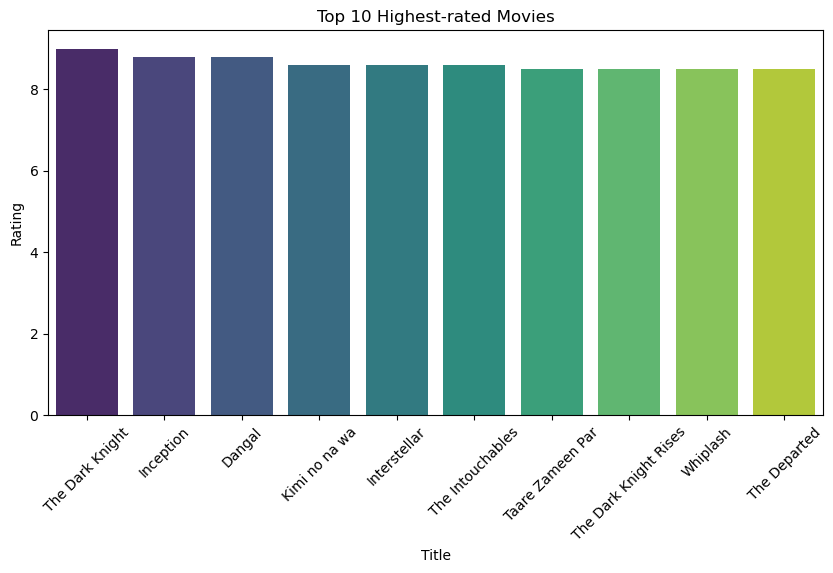

In [52]:
hr_df = highest_rmovies.reset_index()
plt.figure(figsize=(10,5))
sns.barplot(data=hr_df,x='Title',y='Rating',palette='viridis')
plt.title('Top 10 Highest-rated Movies')
plt.xticks(rotation=45)

C:\Users\Admin\AppData\Local\Temp\ipykernel_2912\467614292.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=pop_df,x='Title',y='Popularity_Million',palette='viridis')


([0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 [Text(0, 0, 'The Dark Knight'),
  Text(1, 0, 'Inception'),
  Text(2, 0, 'The Dark Knight Rises'),
  Text(3, 0, 'Interstellar'),
  Text(4, 0, 'Django Unchained'),
  Text(5, 0, 'The Avengers'),
  Text(6, 0, 'The Departed'),
  Text(7, 0, 'Inglourious Basterds'),
  Text(8, 0, 'The Prestige'),
  Text(9, 0, 'Avatar')])

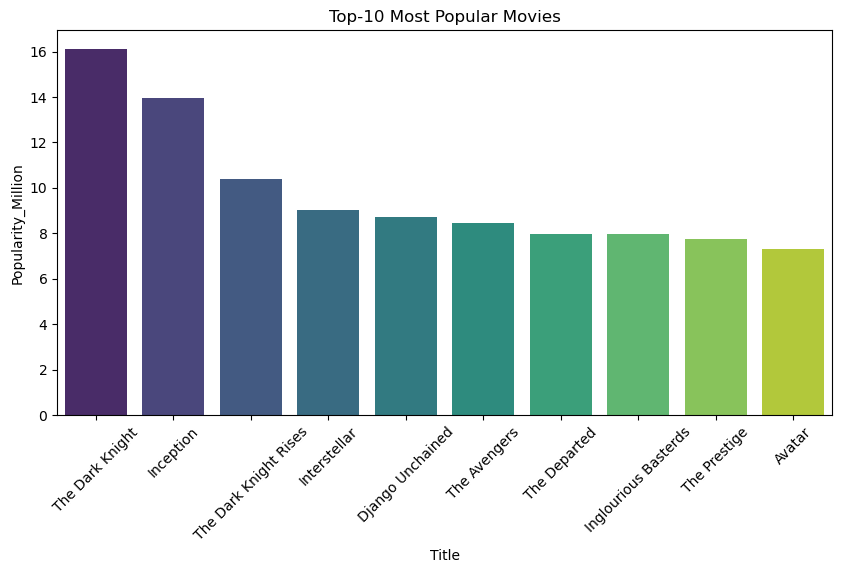

In [51]:
# Top 10 most popular movies

popular_movies = df.groupby('Title')['Popularity'].mean().sort_values(ascending=False).head(10)
pop_df = popular_movies.reset_index()
pop_df['Popularity_Million'] = pop_df['Popularity'] / 1_000_000
plt.figure(figsize=(10,5))
sns.barplot(data=pop_df,x='Title',y='Popularity_Million',palette='viridis')
plt.title('Top-10 Most Popular Movies')
plt.xticks(rotation=45)

## Final Business Insights

#### Genre Dominance & Market Demand:
Action and Adventure genres dominate the dataset in both frequency and popularity, indicating strong and consistent audience demand. This suggests that studios can prioritize these genres to maximize reach and commercial returns.
#### Ratings vs Popularity Relationship:
There is a moderate-to-strong positive correlation (~0.5) between ratings and popularity, indicating that higher-quality movies generally perform better. However, the relationship is not perfect, implying that factors like marketing, star power, and distribution also significantly influence a movie’s success.
#### Performance vs Visibility Gap (Hidden Opportunities):
The presence of highly rated but low-popularity movies highlights a gap between content quality and audience reach. This presents an opportunity for improved marketing strategies, better distribution channels, and targeted audience engagement to unlock additional value.

